In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("hongweicao/catanddogsmall")

print("Path to dataset files:", path)

c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\USER\.cache\kagglehub\datasets\hongweicao\catanddogsmall\versions\1


In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16,ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense,Flatten,Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib as plt


In [9]:
train_path=path+"/dogvscat_small/train"
testing_path=path+"/dogvscat_small/test"
validation_path=path+"/dogvscat_small/validation"

In [10]:
train_data_generator=ImageDataGenerator(
    rescale=1/255,
    rotation_range=15,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

validation_data_generator=ImageDataGenerator(rescale=255)

In [11]:
train_generator=train_data_generator.flow_from_directory(train_path,target_size=(224,224),batch_size=32,class_mode="binary")
validation_generator=validation_data_generator.flow_from_directory(validation_path,target_size=(224,224),batch_size=32,class_mode="binary")
test_generator=validation_data_generator.flow_from_directory(testing_path,target_size=(224,224),batch_size=32,class_mode="binary")

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


In [5]:
base_model=VGG16(weights="imagenet",include_top=False,input_shape=(224,224,3))
#frezzing 
for layer in base_model.layers:
    layer.trainable=False

#unfreezing
for layer in base_model.layers[-4:]:
    layer.trainable=False

x=base_model.output
x=Flatten()(x)
x=Dense(128,activation="relu")(x)
x=Dropout(0.5)(x)
predictions=Dense(1,activation="sigmoid")(x)


In [17]:
from tensorflow.keras.optimizers import Adam

model=Model(inputs=base_model.input,outputs=predictions)

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["Accuracy"])

fitted_model=model.fit(train_generator,epochs=5,validation_data=validation_generator)
loss,accuracy=model.evaluate(test_generator)
print(loss)
print(accuracy)

Epoch 1/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 170s 3s/step - Accuracy: 0.8350 - loss: 0.3879 - val_Accuracy: 0.8980 - val_loss: 1880.3274
Epoch 2/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 160s 3s/step - Accuracy: 0.8350 - loss: 0.3688 - val_Accuracy: 0.8980 - val_loss: 1981.4685
Epoch 3/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 162s 3s/step - Accuracy: 0.8520 - loss: 0.3506 - val_Accuracy: 0.8990 - val_loss: 2052.3987
Epoch 4/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 160s 3s/step - Accuracy: 0.8545 - loss: 0.3369 - val_Accuracy: 0.9000 - val_loss: 2103.9431
Epoch 5/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 176s 3s/step - Accuracy: 0.8545 - loss: 0.3326 - val_Accuracy: 0.9000 - val_loss: 2133.7810
32/32 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step - Accuracy: 0.8980 - loss: 2170.5642
2170.564208984375
0.8980000019073486


In [18]:
image_path=validation_path+"\\dogs\\1009.jpg"
img=image.load_img(image_path,target_size=(224,224))
image_array=image.img_to_array(img)
image_array=np.expand_dims(image_array,axis=0)
image_array=image_array/255
prediction=model.predict(image_array)
print(prediction)
prediction= "cat" if prediction[0]<0.5 else "dog"
print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step
[[0.9756491]]
dog


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [4590.0..65025.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..65025.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..65025.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..65025.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..65025.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..63750.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..65025.0].
Clipping input data to the valid range for im

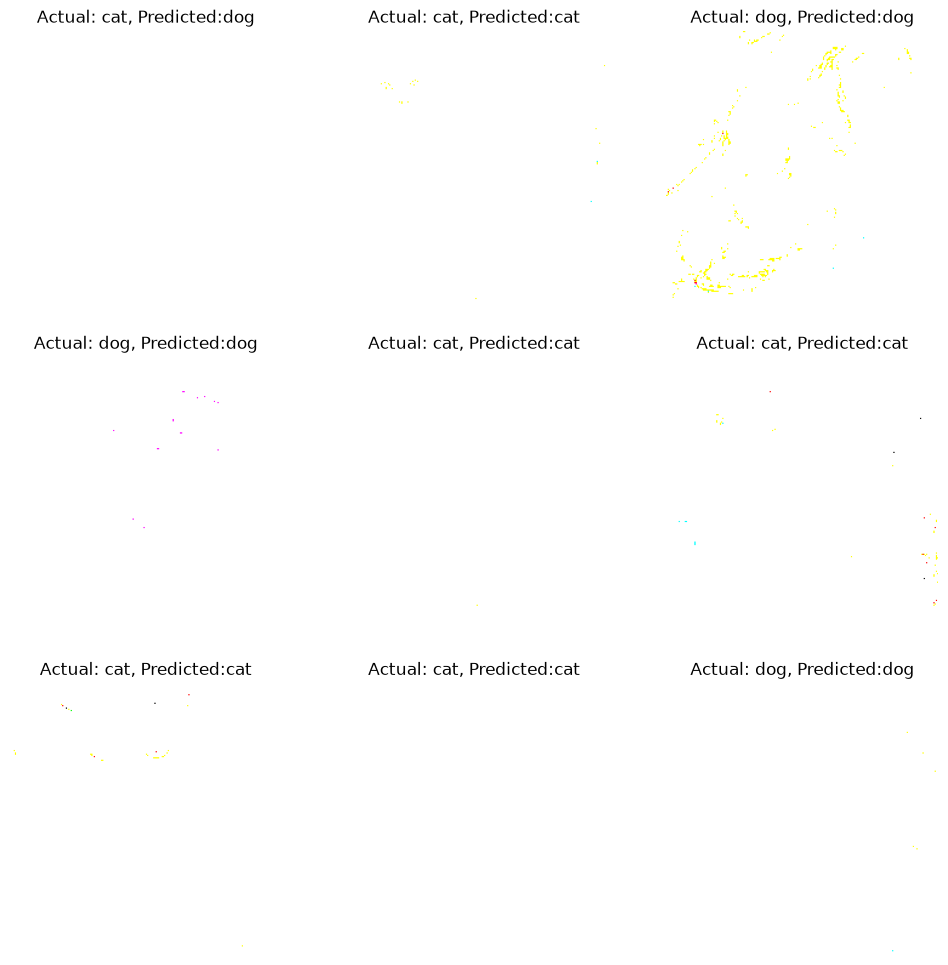

In [ ]:
import matplotlib.pyplot as plt

images,labels=next(validation_generator)
final_prediction=model.predict(images)
plt.figure(figsize=(12,12))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    actual_label= "cat" if labels[i]<0.5 else "dog"
    predicted_label= "cat" if final_prediction[i]<0.5 else "dog"
    plt.title(f"Actual: {actual_label}, Predicted:{predicted_label}")
    plt.axis("off")
plt.show()

